In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import json
import networkx as nx
from pathlib import Path

## Analyze proteins

In [10]:
# =========================
# Load ground truth & data
# =========================
with open("../data/simulated/ards_sim_truth.json", "r", encoding="utf-8") as f:
    truth = json.load(f)

simdata = pd.read_csv("../data/simulated/ards_sim.csv")

# =========================
# Convenience lookups
# =========================
prot_to_pathway = truth["protein_to_pathway"]                     # str → int
pathways_with_effects = set(truth["pathways_with_effects"])       # {3,5,8,...}
pathways_without_effects = set(truth["pathways_without_effects"])
pathway_corr = {int(k): v for k, v in truth["pathway_corr"].items()}

mean_shift_proteins  = list(truth["mean_shift_proteins"])         # 40
shape_change_proteins = list(truth["shape_change_proteins"])      # 30
interaction_proteins  = list(truth["interaction_proteins"])       # 30

# All "effect" / signal proteins (union)
signal_proteins = sorted(set(mean_shift_proteins + shape_change_proteins + interaction_proteins))

mean_shift_params  = truth["mean_shift_params"]   # prot → {mean_ards, std_ards, ...}
shape_change_params = truth["shape_change_params"] # prot → {weights, means, stds, ...}
interaction_pairs   = truth["interaction_pairs"]   # list of dicts {protein_1, protein_2, rho_ards, ...}

# Quick effect-type lookup
effect_type = {}
for p in mean_shift_proteins:
    effect_type[p] = "mean_shift"
for p in shape_change_proteins:
    effect_type[p] = "shape_change"
for p in interaction_proteins:
    effect_type.setdefault(p, "interaction")  # some may overlap

print(f"Proteins: {len(truth['protein_names'])}")
print(f"Pathways: {len(truth['pathway_to_proteins'])}")
print(f"Effect proteins: {len(signal_proteins)} "
      f"(mean_shift={len(mean_shift_proteins)}, "
      f"shape_change={len(shape_change_proteins)}, "
      f"interaction={len(interaction_proteins)})")
print(f"Interaction pairs: {len(interaction_pairs)}")
print(f"Samples: {len(simdata)} (ARDS={int(simdata['ards'].sum())}, "
      f"control={int((simdata['ards']==0).sum())})")

Proteins: 1000
Pathways: 20
Effect proteins: 50 (mean_shift=26, shape_change=10, interaction=14)
Interaction pairs: 7
Samples: 600 (ARDS=120, control=480)


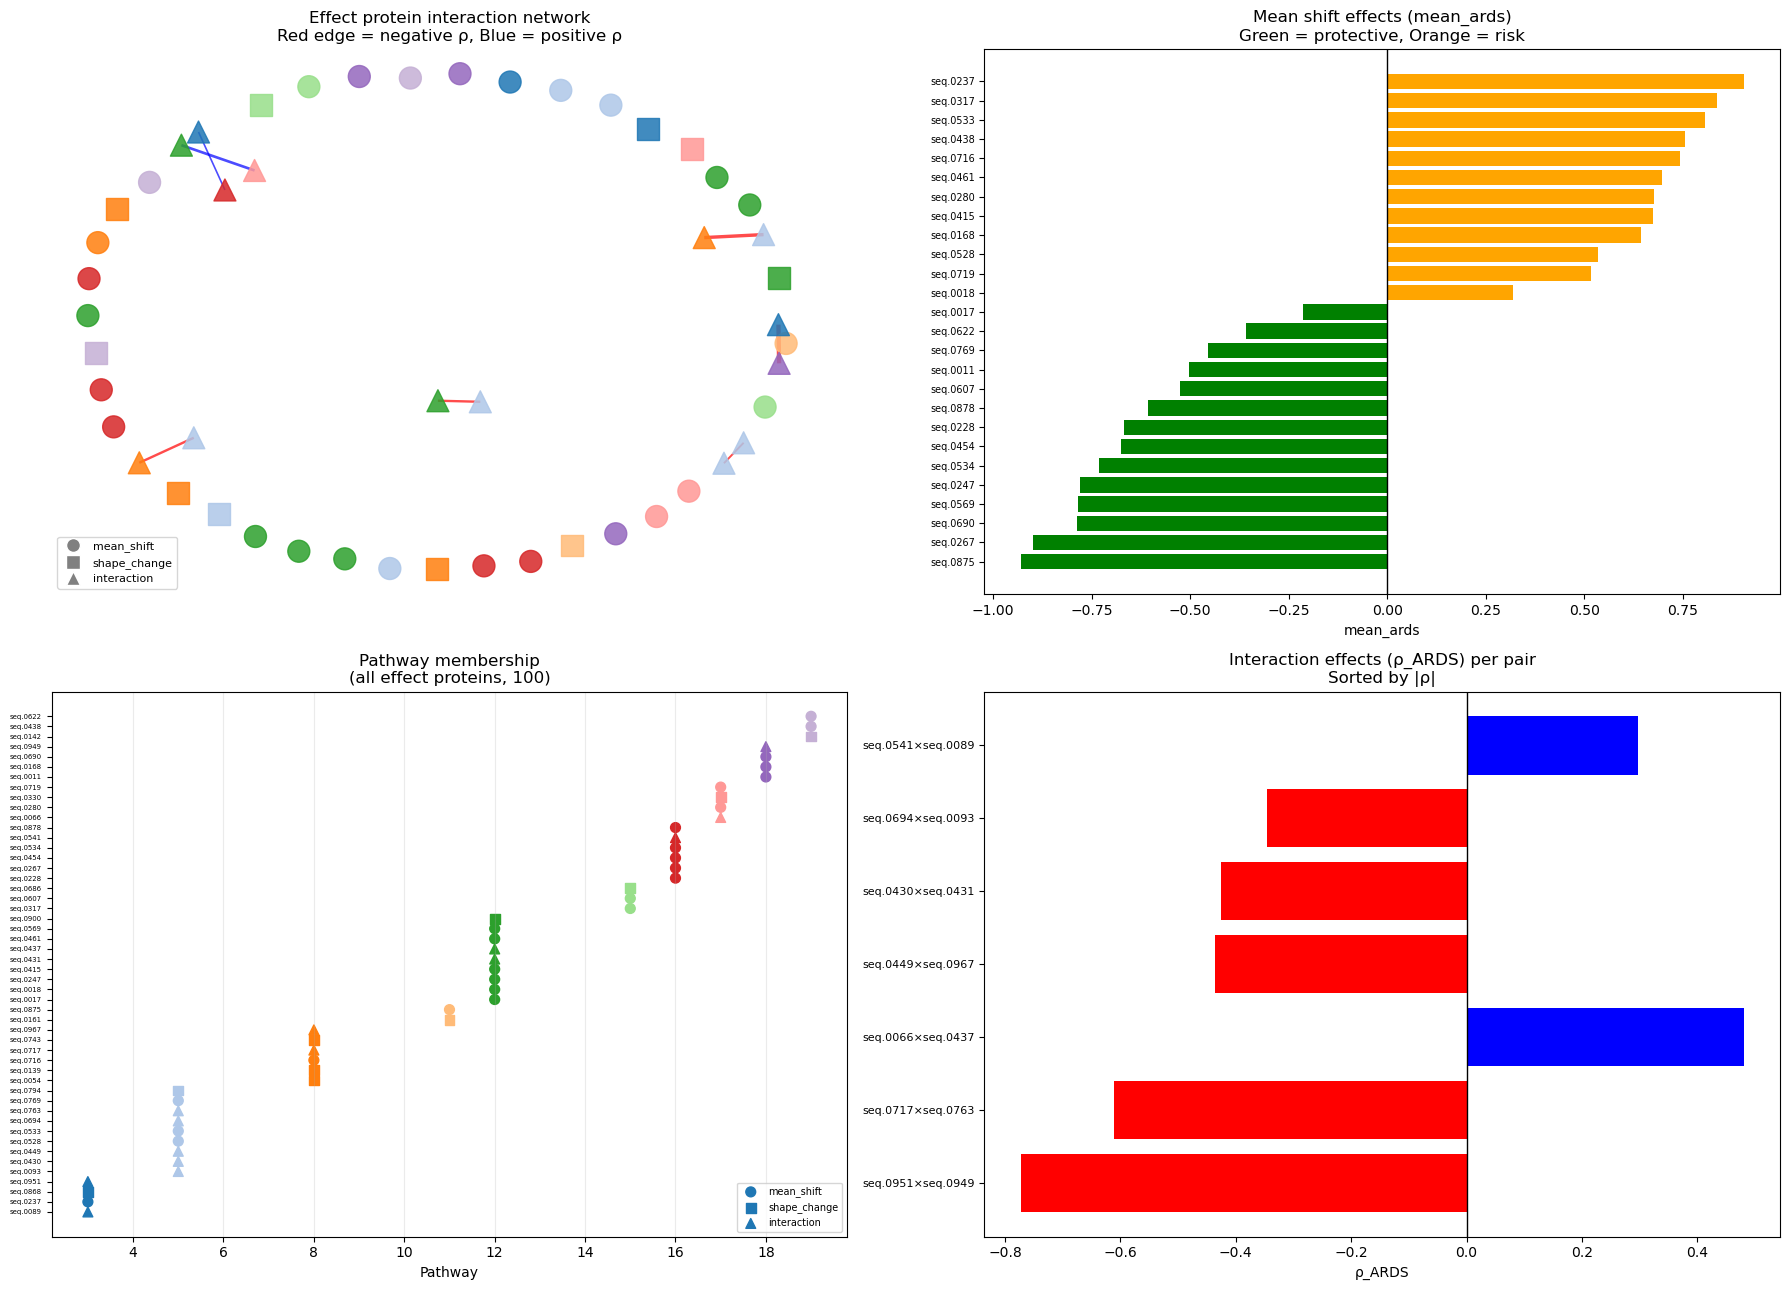

In [11]:
# ==========================================================
# 2×2 Ground Truth Overview
# ==========================================================

# --- build network of effect proteins ---
G = nx.Graph()

for prot in signal_proteins:
    pw = int(prot_to_pathway[prot])
    etype = effect_type.get(prot, "unknown")
    G.add_node(prot, pathway=pw, effect=etype)

for pair in interaction_pairs:
    p1, p2 = pair["protein_1"], pair["protein_2"]
    rho = pair["rho_ards"]
    if p1 in G and p2 in G:
        G.add_edge(p1, p2, rho_ards=rho)

pos = nx.spring_layout(G, seed=42, k=1.8, iterations=300, scale=3)

# --- color by pathway ---
pathways_in_graph = [G.nodes[n]["pathway"] for n in G.nodes]
unique_paths = sorted(set(pathways_in_graph))
cmap = plt.cm.tab20
color_map = {p: cmap((i % 20) / 20) for i, p in enumerate(unique_paths)}
node_colors = [color_map[G.nodes[n]["pathway"]] for n in G.nodes]

# --- node shapes by effect type ---
marker_map = {"mean_shift": "o", "shape_change": "s", "interaction": "^"}

# =========================
# Plot: 2×2 subplots
# =========================
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
ax_net, ax_mean, ax_path, ax_rho = axes.flatten()

# ---- (1) Interaction Network ----
for etype_key, marker in marker_map.items():
    nodelist = [n for n in G.nodes if G.nodes[n]["effect"] == etype_key]
    if not nodelist:
        continue
    colors = [color_map[G.nodes[n]["pathway"]] for n in nodelist]
    nx.draw_networkx_nodes(
        G, pos, nodelist=nodelist, node_color=colors,
        node_shape=marker, node_size=250, ax=ax_net, alpha=0.85
    )

edges = list(G.edges(data=True))
if edges:
    edge_colors = ["red" if d["rho_ards"] < 0 else "blue" for (_, _, d) in edges]
    edge_widths = [max(0.8, abs(d["rho_ards"]) * 4) for (_, _, d) in edges]
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, ax=ax_net, alpha=0.7)

# legend for node shapes
shape_legend = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="grey", markersize=10, label="mean_shift"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="grey", markersize=10, label="shape_change"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="grey", markersize=10, label="interaction"),
]
ax_net.legend(handles=shape_legend, loc="lower left", fontsize=8, framealpha=0.8)
ax_net.set_title("Effect protein interaction network\nRed edge = negative ρ, Blue = positive ρ")
ax_net.axis("off")

# ---- (2) Mean shift effects (analogous to β) ----
ms_names = list(mean_shift_params.keys())
ms_values = np.array([mean_shift_params[p]["mean_ards"] for p in ms_names])

order = np.argsort(ms_values)
ms_sorted = ms_values[order]
names_sorted = [ms_names[i] for i in order]
colors_ms = ["green" if v < 0 else "orange" for v in ms_sorted]

ax_mean.barh(names_sorted, ms_sorted, color=colors_ms)
ax_mean.axvline(0, color="black", linewidth=1)
ax_mean.set_title("Mean shift effects (mean_ards)\nGreen = protective, Orange = risk")
ax_mean.set_xlabel("mean_ards")
ax_mean.tick_params(axis="y", labelsize=7)

# ---- (3) Pathway membership for all effect proteins ----
sig_pathways = [int(prot_to_pathway[p]) for p in signal_proteins]
order_pw = np.lexsort((
    [int(p.split(".")[1]) for p in signal_proteins],
    sig_pathways
))
sig_sorted = [signal_proteins[i] for i in order_pw]
pw_sorted  = [sig_pathways[i] for i in order_pw]

y = np.arange(len(sig_sorted))

# draw by effect type with different markers
for etype_key, marker in marker_map.items():
    mask = [effect_type.get(sig_sorted[i], "") == etype_key for i in range(len(sig_sorted))]
    idx = [i for i, m in enumerate(mask) if m]
    if idx:
        ax_path.scatter(
            [pw_sorted[i] for i in idx],
            [y[i] for i in idx],
            s=50, marker=marker,
            c=[color_map[pw_sorted[i]] for i in idx],
            label=etype_key
        )

ax_path.set_yticks(y)
ax_path.set_yticklabels(sig_sorted, fontsize=5)
ax_path.set_xlabel("Pathway")
ax_path.set_title("Pathway membership\n(all effect proteins, 100)")
ax_path.legend(fontsize=7, loc="lower right")
ax_path.grid(axis="x", alpha=0.25)

# ---- (4) Interaction effects (ρ_ARDS) per pair ----
pair_names = [f"{p['protein_1']}×{p['protein_2']}" for p in interaction_pairs]
rho_values = np.array([p["rho_ards"] for p in interaction_pairs])

order_rho = np.argsort(np.abs(rho_values))[::-1]
rho_sorted = rho_values[order_rho]
pair_sorted = [pair_names[i] for i in order_rho]
rho_colors = ["red" if r < 0 else "blue" for r in rho_sorted]

ax_rho.barh(pair_sorted, rho_sorted, color=rho_colors)
ax_rho.axvline(0, color="black", linewidth=1)
ax_rho.set_title("Interaction effects (ρ_ARDS) per pair\nSorted by |ρ|")
ax_rho.set_xlabel("ρ_ARDS")
ax_rho.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

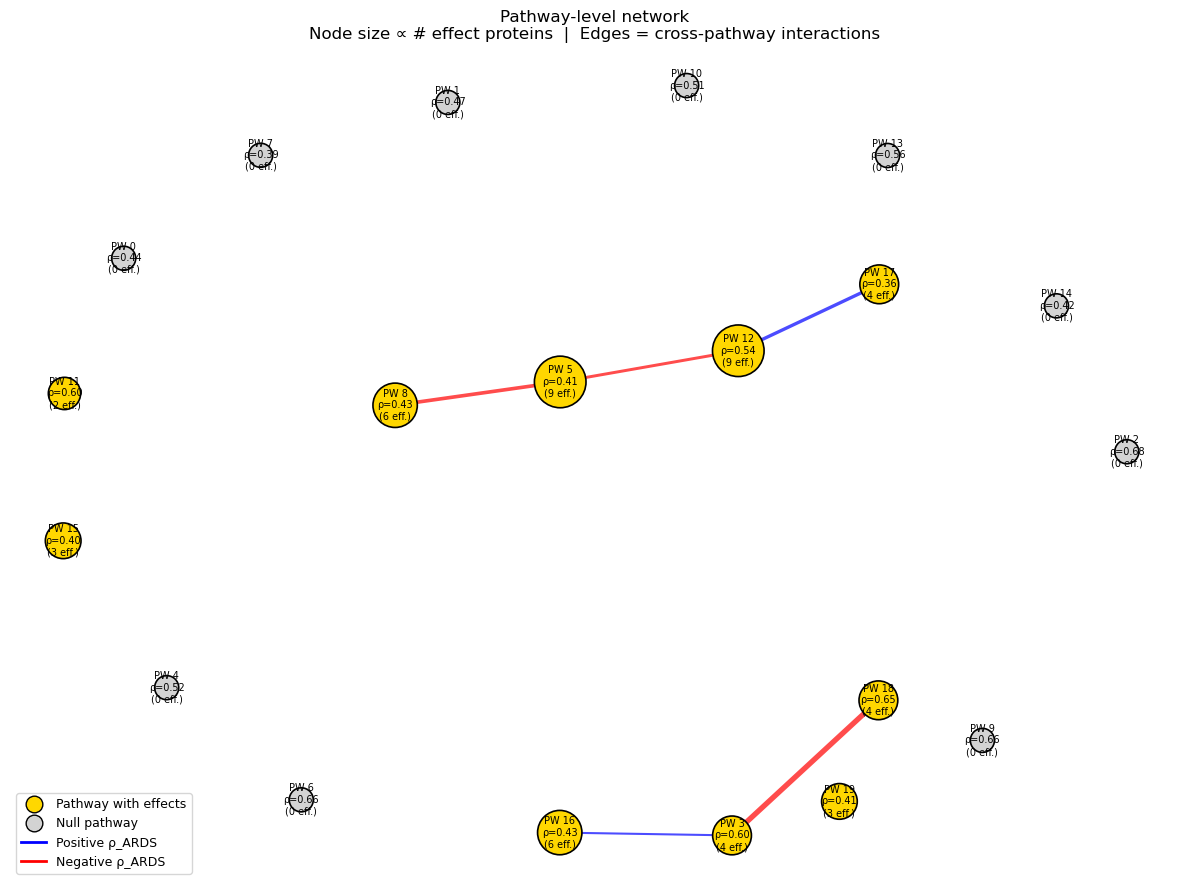

In [12]:
# ==========================================================
# Pathway-level Network
# ==========================================================
PG = nx.Graph()

all_pathways = sorted(int(k) for k in truth["pathway_to_proteins"].keys())

for pw in all_pathways:
    # count effect proteins in this pathway
    members = truth["pathway_to_proteins"][str(pw)]
    n_effect = sum(1 for m in members if m in set(signal_proteins))
    has_effect = pw in pathways_with_effects
    rho_pw = pathway_corr.get(pw, 0)
    PG.add_node(pw, n_effect=n_effect, has_effect=has_effect, corr=rho_pw)

# edges from cross-pathway interaction pairs
for pair in interaction_pairs:
    pw1 = int(prot_to_pathway[pair["protein_1"]])
    pw2 = int(prot_to_pathway[pair["protein_2"]])
    if pw1 != pw2:
        if PG.has_edge(pw1, pw2):
            # accumulate multiple edges between same pathway pair
            existing = PG[pw1][pw2]["pairs"]
            existing.append(pair["rho_ards"])
        else:
            PG.add_edge(pw1, pw2, pairs=[pair["rho_ards"]])

pos_pw = nx.spring_layout(PG, seed=7, k=2.5, iterations=200, scale=3)

fig, ax = plt.subplots(figsize=(12, 9))

# node colors and sizes
pw_colors = ["gold" if PG.nodes[n]["has_effect"] else "lightgrey" for n in PG.nodes]
pw_sizes  = [300 + PG.nodes[n]["n_effect"] * 120 for n in PG.nodes]

nx.draw_networkx_nodes(PG, pos_pw, node_color=pw_colors, node_size=pw_sizes,
                       edgecolors="black", linewidths=1.2, ax=ax)

# edges — use mean rho if multiple pairs share same pathway pair
for (u, v, d) in PG.edges(data=True):
    mean_rho = np.mean(d["pairs"])
    ecolor = "red" if mean_rho < 0 else "blue"
    ewidth = max(1, abs(mean_rho) * 5)
    nx.draw_networkx_edges(PG, pos_pw, edgelist=[(u, v)],
                           edge_color=[ecolor], width=ewidth, alpha=0.7, ax=ax)

# labels: pathway ID + within-pathway correlation
labels = {n: f"PW {n}\nρ={PG.nodes[n]['corr']:.2f}\n({PG.nodes[n]['n_effect']} eff.)"
          for n in PG.nodes}
nx.draw_networkx_labels(PG, pos_pw, labels=labels, font_size=7, ax=ax)

# legend
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gold",
           markersize=12, markeredgecolor="k", label="Pathway with effects"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="lightgrey",
           markersize=12, markeredgecolor="k", label="Null pathway"),
    Line2D([0], [0], color="blue", linewidth=2, label="Positive ρ_ARDS"),
    Line2D([0], [0], color="red", linewidth=2, label="Negative ρ_ARDS"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=9)
ax.set_title("Pathway-level network\nNode size ∝ # effect proteins  |  Edges = cross-pathway interactions")
ax.axis("off")
plt.tight_layout()
plt.show()

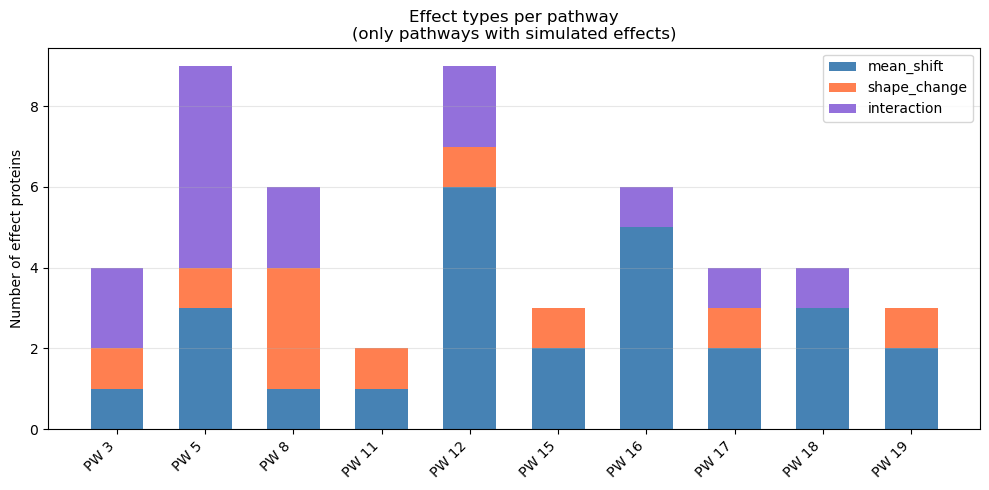

In [13]:
# ==========================================================
# Effect type breakdown per pathway (stacked bar)
# ==========================================================
effect_pathways = sorted(pathways_with_effects)

ms_set = set(mean_shift_proteins)
sc_set = set(shape_change_proteins)
ip_set = set(interaction_proteins)

counts_ms, counts_sc, counts_ip = [], [], []
for pw in effect_pathways:
    members = truth["pathway_to_proteins"][str(pw)]
    counts_ms.append(sum(1 for m in members if m in ms_set))
    counts_sc.append(sum(1 for m in members if m in sc_set))
    counts_ip.append(sum(1 for m in members if m in ip_set))

x = np.arange(len(effect_pathways))
width = 0.6

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x, counts_ms, width, label="mean_shift", color="steelblue")
b2 = ax.bar(x, counts_sc, width, bottom=counts_ms, label="shape_change", color="coral")
bottom_ip = np.array(counts_ms) + np.array(counts_sc)
b3 = ax.bar(x, counts_ip, width, bottom=bottom_ip, label="interaction", color="mediumpurple")

ax.set_xticks(x)
ax.set_xticklabels([f"PW {p}" for p in effect_pathways], rotation=45, ha="right")
ax.set_ylabel("Number of effect proteins")
ax.set_title("Effect types per pathway\n(only pathways with simulated effects)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

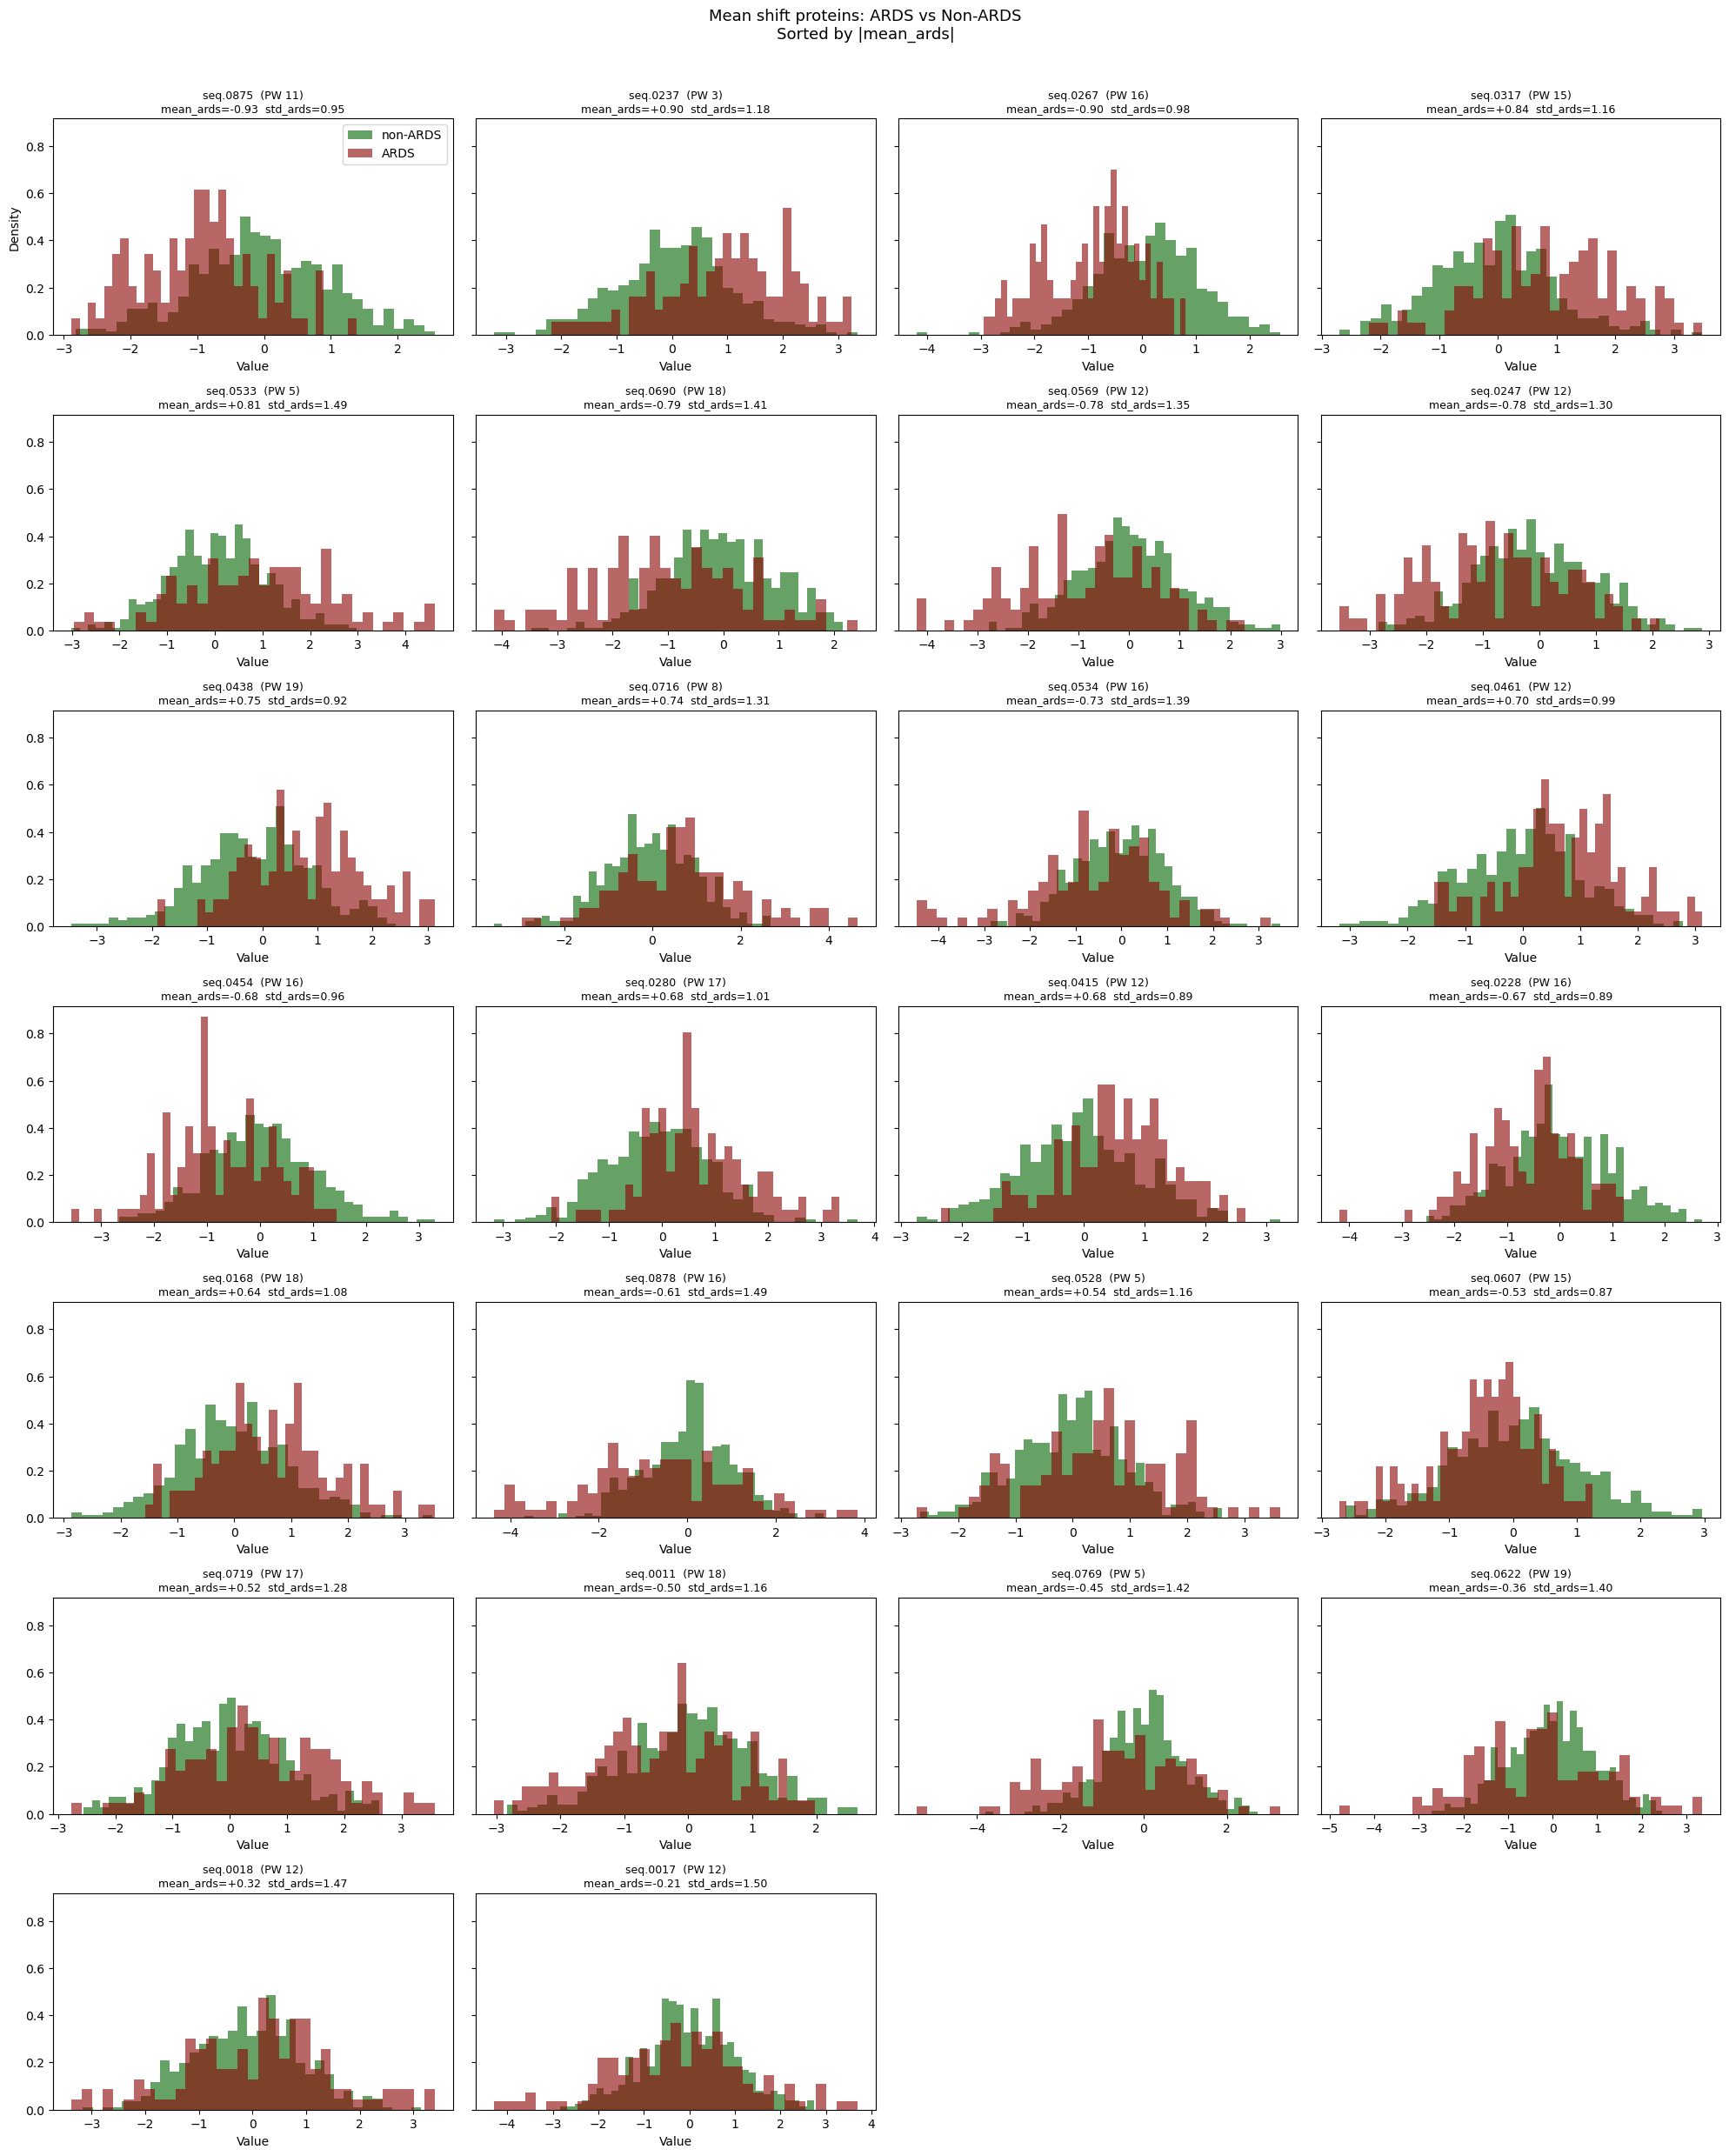

In [14]:
# ==========================================================
# Mean shift proteins: ARDS vs Non-ARDS distributions
# ==========================================================
n_ms = len(mean_shift_proteins)
ncols = 4
nrows = int(np.ceil(n_ms / ncols))

# sort by absolute mean_ards (strongest effect first)
ms_order = sorted(mean_shift_proteins,
                  key=lambda p: abs(mean_shift_params[p]["mean_ards"]), reverse=True)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharey=True)
axes = np.array(axes).ravel()

for i, ax in enumerate(axes):
    if i >= n_ms:
        ax.axis("off")
        continue

    prot = ms_order[i]
    params = mean_shift_params[prot]
    pw = int(prot_to_pathway[prot])

    non = simdata.loc[simdata["ards"] == 0, prot].values
    ards = simdata.loc[simdata["ards"] == 1, prot].values

    ax.hist(non, bins=35, alpha=0.6, density=True, color="darkgreen", label="non-ARDS")
    ax.hist(ards, bins=35, alpha=0.6, density=True, color="darkred", label="ARDS")

    ax.set_title(
        f"{prot}  (PW {pw})\n"
        f"mean_ards={params['mean_ards']:+.2f}  std_ards={params['std_ards']:.2f}",
        fontsize=9
    )
    ax.set_xlabel("Value")

axes[0].set_ylabel("Density")
axes[0].legend()

plt.suptitle("Mean shift proteins: ARDS vs Non-ARDS\nSorted by |mean_ards|", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

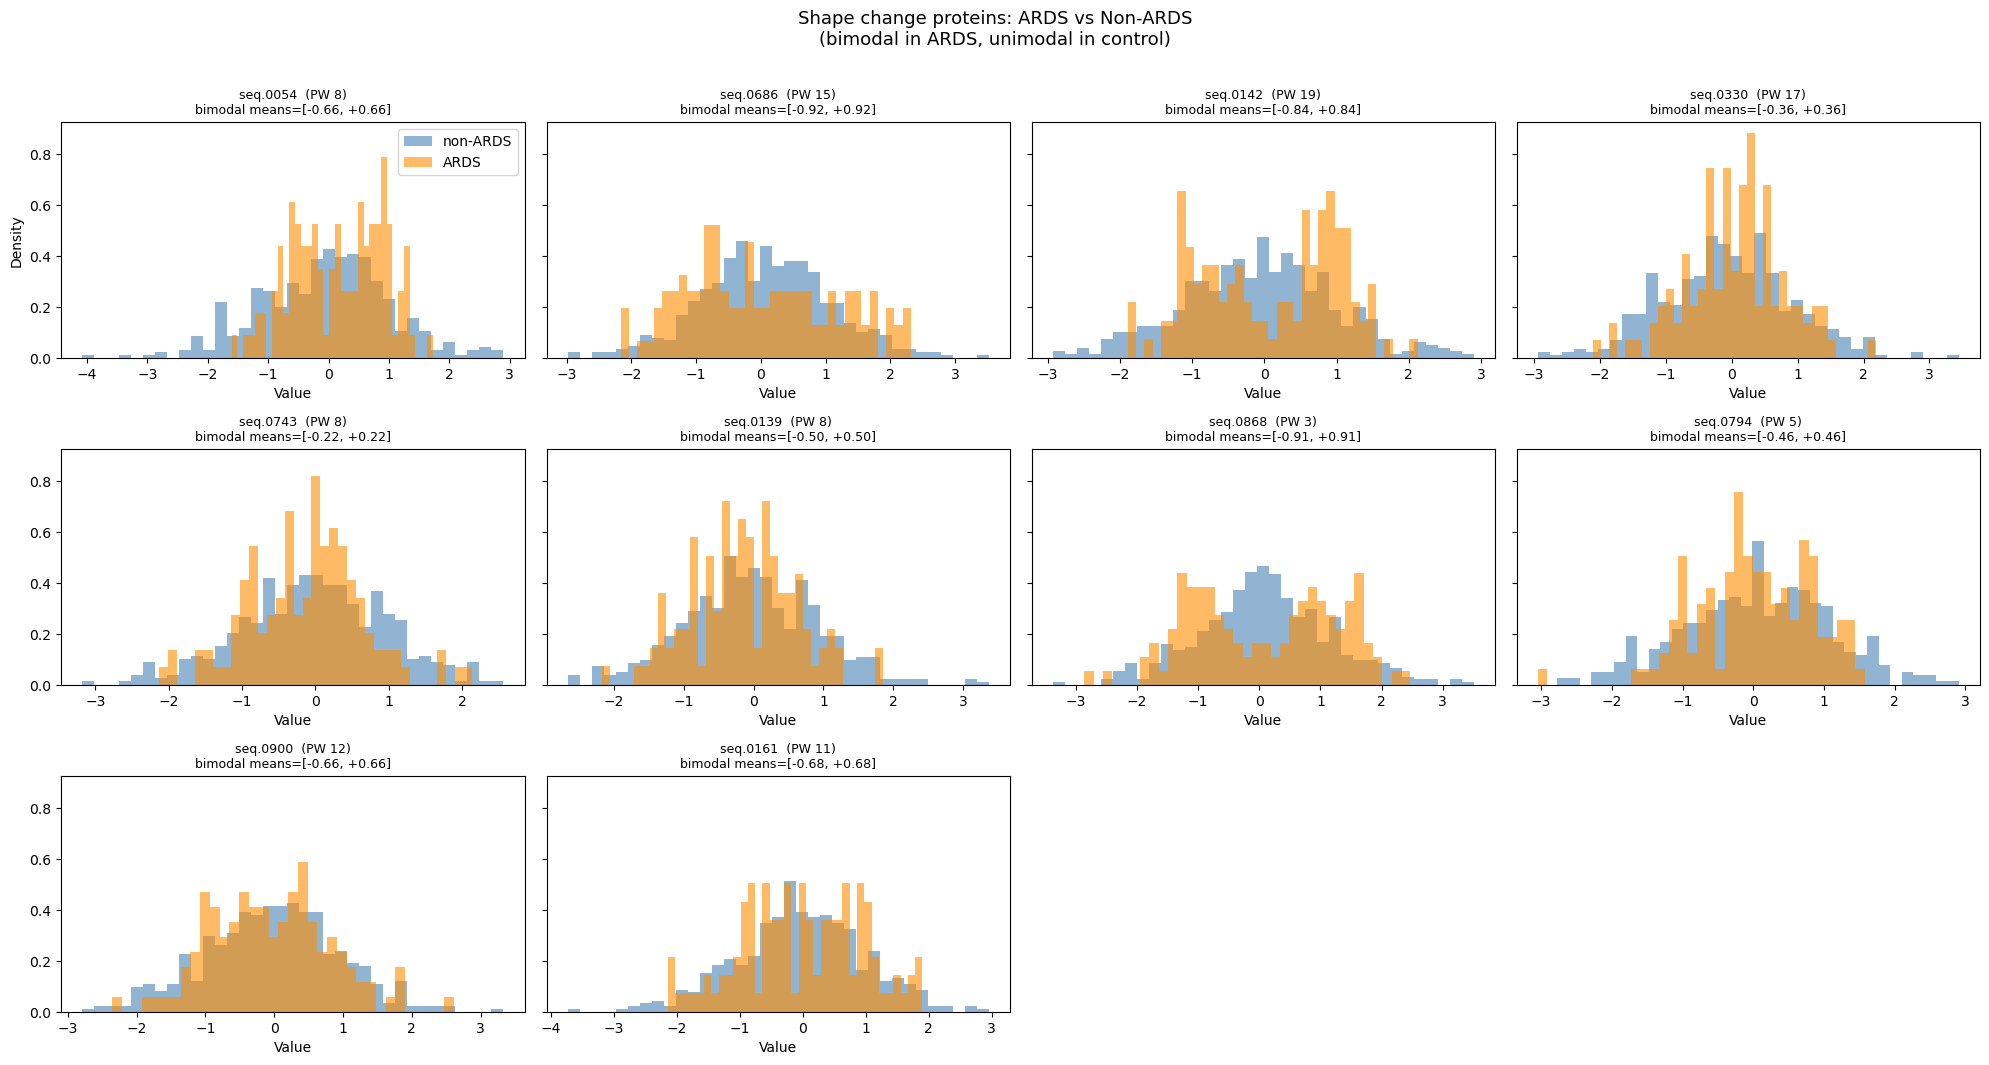

In [15]:
# ==========================================================
# Shape change proteins: ARDS vs Non-ARDS distributions
# ==========================================================
n_sc = len(shape_change_proteins)
ncols = 4
nrows = int(np.ceil(n_sc / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharey=True)
axes = np.array(axes).ravel()

for i, ax in enumerate(axes):
    if i >= n_sc:
        ax.axis("off")
        continue

    prot = shape_change_proteins[i]
    params = shape_change_params[prot]
    pw = int(prot_to_pathway[prot])

    non = simdata.loc[simdata["ards"] == 0, prot].values
    ards = simdata.loc[simdata["ards"] == 1, prot].values

    ax.hist(non, bins=35, alpha=0.6, density=True, color="steelblue", label="non-ARDS")
    ax.hist(ards, bins=35, alpha=0.6, density=True, color="darkorange", label="ARDS")

    # show bimodal means in title
    m1, m2 = params["means"]
    ax.set_title(
        f"{prot}  (PW {pw})\n"
        f"bimodal means=[{m1:+.2f}, {m2:+.2f}]",
        fontsize=9
    )
    ax.set_xlabel("Value")

axes[0].set_ylabel("Density")
axes[0].legend()

plt.suptitle("Shape change proteins: ARDS vs Non-ARDS\n(bimodal in ARDS, unimodal in control)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

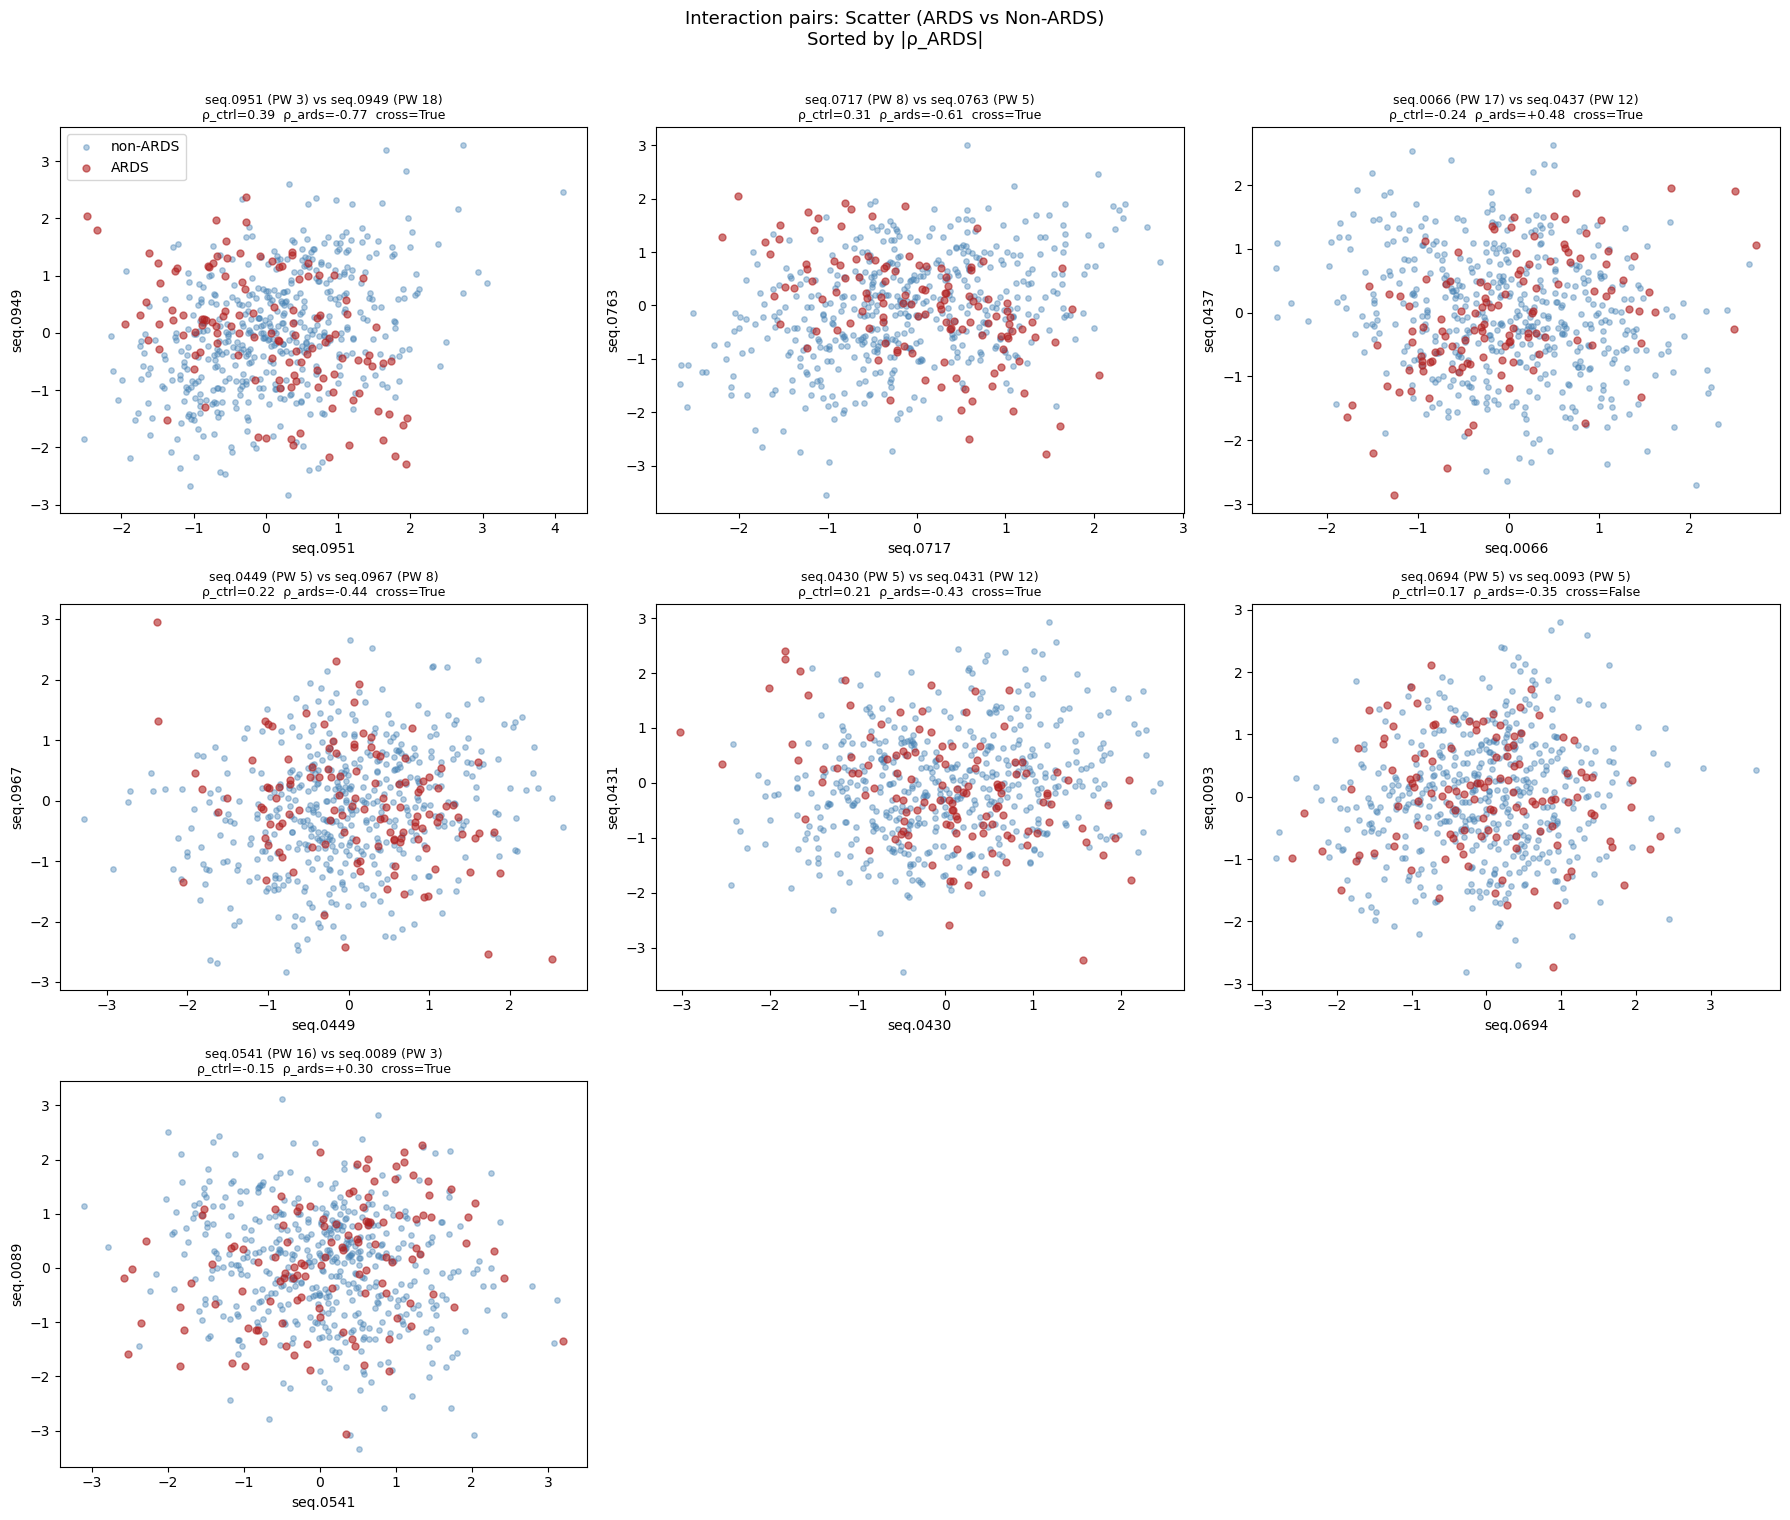

In [16]:
# ==========================================================
# Interaction pairs: Scatter plots (ARDS vs Non-ARDS)
# ==========================================================
n_pairs = len(interaction_pairs)
ncols = 3
nrows = int(np.ceil(n_pairs / ncols))

# sort by |rho_ards| (strongest first)
pairs_sorted = sorted(interaction_pairs, key=lambda p: abs(p["rho_ards"]), reverse=True)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).ravel()

mask_ards = simdata["ards"] == 1

for i, ax in enumerate(axes):
    if i >= n_pairs:
        ax.axis("off")
        continue

    pair = pairs_sorted[i]
    p1, p2 = pair["protein_1"], pair["protein_2"]
    rho_a = pair["rho_ards"]
    rho_c = pair["rho_control"]
    cross = pair["cross_pathway"]

    x1 = simdata[p1].values
    x2 = simdata[p2].values

    ax.scatter(x1[~mask_ards], x2[~mask_ards], alpha=0.4, s=15, color="steelblue", label="non-ARDS")
    ax.scatter(x1[mask_ards],  x2[mask_ards],  alpha=0.6, s=25, color="firebrick",  label="ARDS")

    pw1 = int(prot_to_pathway[p1])
    pw2 = int(prot_to_pathway[p2])

    ax.set_title(
        f"{p1} (PW {pw1}) vs {p2} (PW {pw2})\n"
        f"ρ_ctrl={rho_c:.2f}  ρ_ards={rho_a:+.2f}  cross={cross}",
        fontsize=9
    )
    ax.set_xlabel(p1)
    ax.set_ylabel(p2)

axes[0].legend()
plt.suptitle("Interaction pairs: Scatter (ARDS vs Non-ARDS)\nSorted by |ρ_ARDS|", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## Protein look-up

In [19]:
def _normalize_protein_id(x):
    s = str(x).strip().lower().replace("seq.", "")
    if s.isdigit() and 1 <= int(s) <= 1000:
        return f"seq.{int(s):04d}"
    return None


def describe_protein(protein_input):
    prot = _normalize_protein_id(protein_input)
    if prot is None:
        print(f"Invalid protein id: {protein_input}. Use format like 0011 or seq.0011")
        return

    if prot not in prot_to_pathway:
        print(f"{prot} is not present in protein_to_pathway")
        return

    pw = int(prot_to_pathway[prot])
    effects = []

    if prot in mean_shift_proteins:
        effects.append("mean_shift")
    if prot in shape_change_proteins:
        effects.append("shape_change")
    if prot in interaction_proteins:
        effects.append("interaction")

    print(f"Protein: {prot}")
    print(f"Pathway: {pw}")

    if not effects:
        print("Effect: none (null protein)")
        return

    print(f"Effect(s): {', '.join(effects)}")

    if "mean_shift" in effects:
        ms = mean_shift_params[prot]
        print(
            f"  mean_shift params: mean_control={ms['mean_control']:+.2f}, "
            f"std_control={ms['std_control']:.2f}, mean_ards={ms['mean_ards']:+.2f}, "
            f"std_ards={ms['std_ards']:.2f}"
        )

    if "shape_change" in effects:
        sc = shape_change_params[prot]
        print(
            f"  shape_change params: weights={sc['weights']}, "
            f"means={[round(v, 2) for v in sc['means']]}, "
            f"stds={[round(v, 2) for v in sc['stds']]}"
        )

    if "interaction" in effects:
        pairs_for_prot = [
            p for p in interaction_pairs
            if p["protein_1"] == prot or p["protein_2"] == prot
        ]
        print(f"  interaction pairs ({len(pairs_for_prot)}):")
        for p in pairs_for_prot:
            other = p["protein_2"] if p["protein_1"] == prot else p["protein_1"]
            print(
                f"    with {other}: rho_control={p['rho_control']:+.2f}, "
                f"rho_ards={p['rho_ards']:+.2f}, cross_pathway={p['cross_pathway']}"
            )

In [28]:
# Enter protein number as xxxx (e.g., "0011")
protein_number = "0533"

# Run lookup
describe_protein(protein_number)

Protein: seq.0533
Pathway: 5
Effect(s): mean_shift
  mean_shift params: mean_control=+0.00, std_control=1.00, mean_ards=+0.81, std_ards=1.49


## Compare methods

In [29]:
# ==========================================================
# Load feature selection results
# ==========================================================
features_ttest = pd.read_csv("../results/sim/ttest/selected_features_k100.csv")
features_mi_fs = pd.read_csv("../results/sim/mi_fs/selected_features_n_features100.csv")

rank_ttest = list(features_ttest["protein"].astype(str))
rank_mi_fs = list(features_mi_fs["protein"].astype(str))

ms_set = set(mean_shift_proteins)
sc_set = set(shape_change_proteins)
ip_set = set(interaction_proteins)
signal_set = set(signal_proteins)

def categorize(prot):
    cats = []
    if prot in ms_set:
        cats.append("mean_shift")
    if prot in sc_set:
        cats.append("shape_change")
    if prot in ip_set:
        cats.append("interaction")
    return ", ".join(cats) if cats else "null"

def annotate_list(ranked_list, method_name):
    rows = []
    for rank, prot in enumerate(ranked_list, 1):
        pw = int(prot_to_pathway.get(prot, -1))
        cat = categorize(prot)
        rows.append({
            "method": method_name,
            "rank": rank,
            "protein": prot,
            "pathway": pw,
            "category": cat,
            "is_effect": prot in signal_set,
            "pw_has_effect": pw in pathways_with_effects,
        })
    return pd.DataFrame(rows)

df_ttest = annotate_list(rank_ttest, "t-test")
df_mi_fs = annotate_list(rank_mi_fs, "MI-FS")

print(f"t-test: {len(df_ttest)} features loaded")
print(f"MI-FS:  {len(df_mi_fs)} features loaded")

t-test: 100 features loaded
MI-FS:  100 features loaded


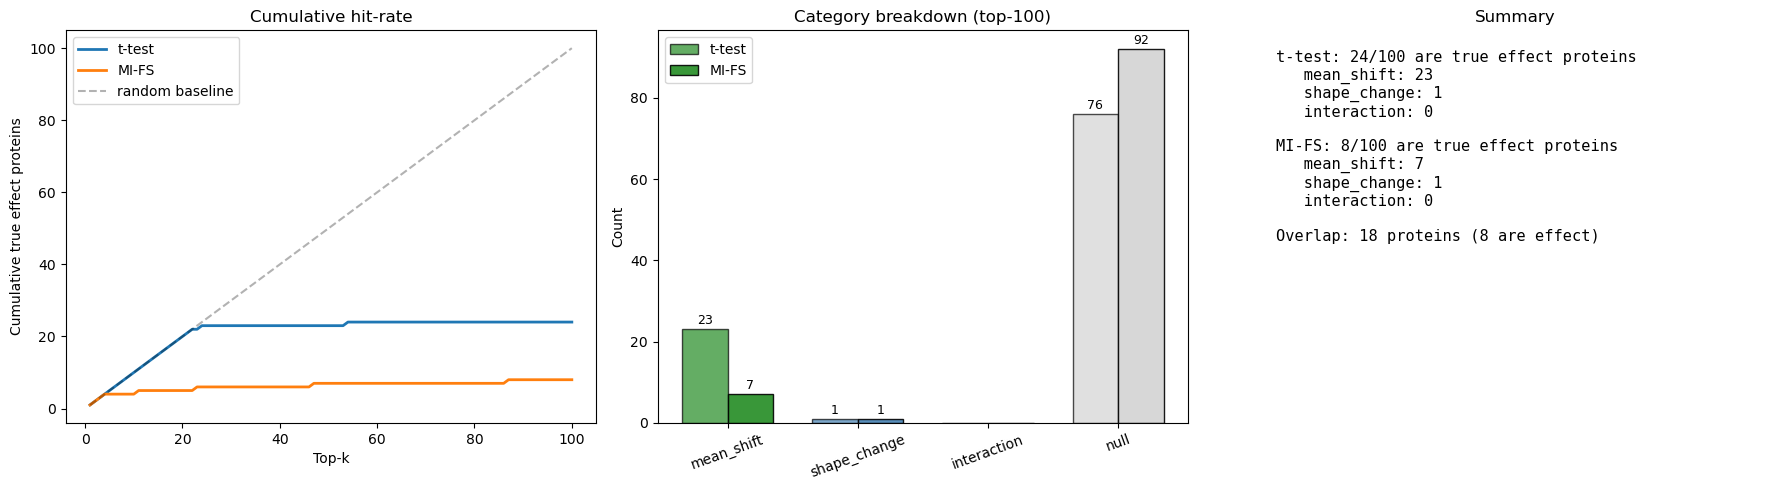

In [30]:
# ==========================================================
# Effect hit counts & category breakdown  (cumulative + bar)
# ==========================================================
df_all = pd.concat([df_ttest, df_mi_fs], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Cumulative hit-rate curve ---
ax = axes[0]
for method, df in [("t-test", df_ttest), ("MI-FS", df_mi_fs)]:
    cum_hits = df["is_effect"].cumsum().values
    ax.plot(range(1, len(cum_hits) + 1), cum_hits, label=method, linewidth=2)
ax.plot([1, 100], [1, 100], "k--", alpha=0.3, label="random baseline")
ax.set_xlabel("Top-k")
ax.set_ylabel("Cumulative true effect proteins")
ax.set_title("Cumulative hit-rate")
ax.legend()

# --- 2. Category breakdown bars ---
ax = axes[1]
categories = ["mean_shift", "shape_change", "interaction", "null"]
cat_colors = {"mean_shift": "forestgreen", "shape_change": "steelblue",
              "interaction": "darkorange", "null": "lightgrey"}

x_pos = np.arange(len(categories))
w = 0.35

for i, (method, df) in enumerate([("t-test", df_ttest), ("MI-FS", df_mi_fs)]):
    counts = [df["category"].str.contains(c).sum() if c != "null"
              else (df["category"] == "null").sum() for c in categories]
    bars = ax.bar(x_pos + i * w, counts, w, label=method,
                  color=[cat_colors[c] for c in categories], edgecolor="black",
                  alpha=0.7 + 0.2 * i)
    for bar, cnt in zip(bars, counts):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    str(cnt), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x_pos + w / 2)
ax.set_xticklabels(categories, rotation=20)
ax.set_ylabel("Count")
ax.set_title("Category breakdown (top-100)")
ax.legend()

# --- 3. Text summary ---
ax = axes[2]
ax.axis("off")
lines = []
for method, df in [("t-test", df_ttest), ("MI-FS", df_mi_fs)]:
    n_hit = df["is_effect"].sum()
    lines.append(f"{method}: {n_hit}/100 are true effect proteins")
    for c in ["mean_shift", "shape_change", "interaction"]:
        n_c = df["category"].str.contains(c).sum()
        lines.append(f"   {c}: {n_c}")
    lines.append("")
# overlap
overlap = set(df_ttest["protein"]) & set(df_mi_fs["protein"])
overlap_signal = overlap & signal_set
lines.append(f"Overlap: {len(overlap)} proteins ({len(overlap_signal)} are effect)")
ax.text(0.05, 0.95, "\n".join(lines), transform=ax.transAxes,
        va="top", fontsize=11, family="monospace")
ax.set_title("Summary")

plt.tight_layout()
plt.show()

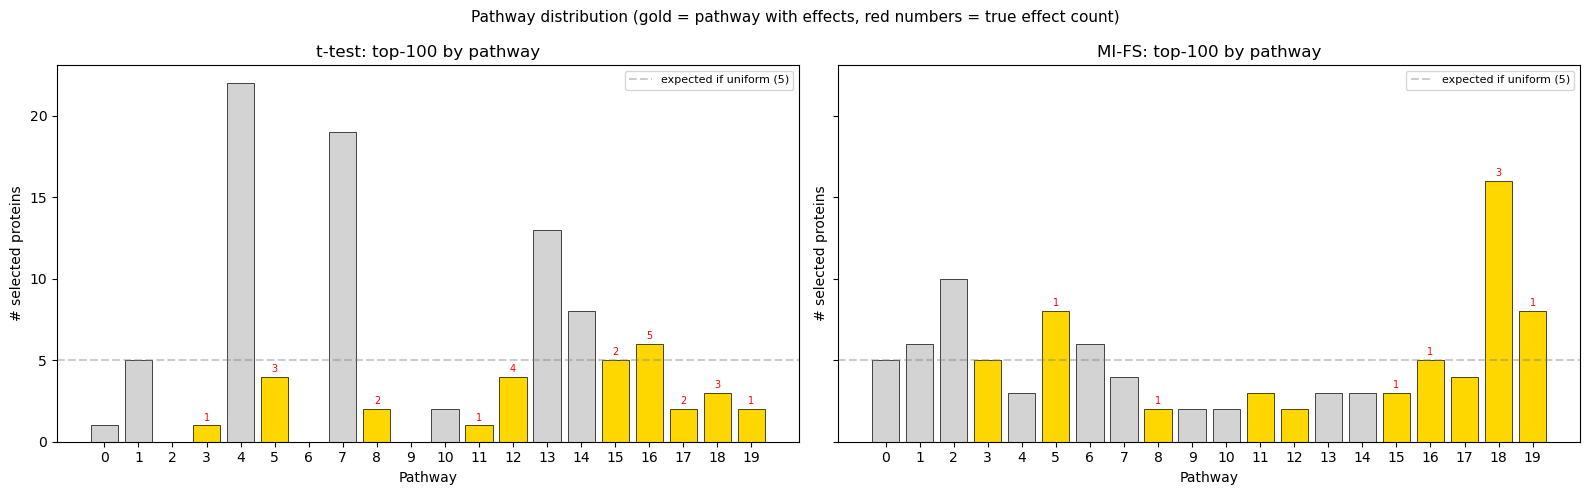

In [31]:
# ==========================================================
# Pathway distribution of selected features
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (method, df) in zip(axes, [("t-test", df_ttest), ("MI-FS", df_mi_fs)]):
    pw_counts = df["pathway"].value_counts().sort_index()
    all_pw = range(20)
    counts = [pw_counts.get(pw, 0) for pw in all_pw]
    bar_colors = ["gold" if pw in pathways_with_effects else "lightgrey" for pw in all_pw]
    ax.bar(all_pw, counts, color=bar_colors, edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Pathway")
    ax.set_ylabel("# selected proteins")
    ax.set_title(f"{method}: top-100 by pathway")
    ax.set_xticks(all_pw)
    ax.axhline(5, color="grey", ls="--", alpha=0.4, label="expected if uniform (5)")
    ax.legend(fontsize=8)

    # annotate with effect counts
    for pw in all_pw:
        n = counts[pw]
        if n > 0:
            n_eff = df[(df["pathway"] == pw) & df["is_effect"]].shape[0]
            if n_eff > 0:
                ax.text(pw, n + 0.3, f"{n_eff}", ha="center", fontsize=7, color="red")

fig.suptitle("Pathway distribution (gold = pathway with effects, red numbers = true effect count)",
             fontsize=11)
plt.tight_layout()
plt.show()

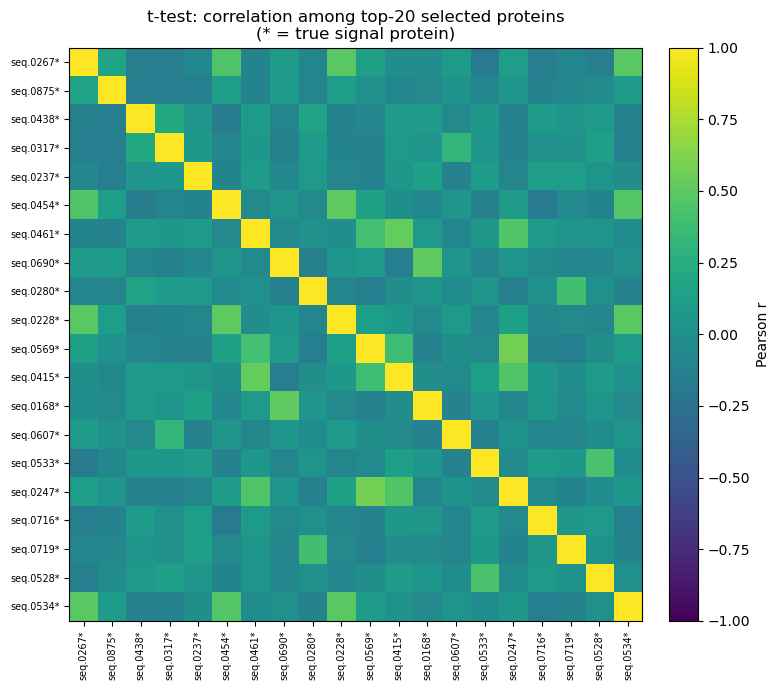

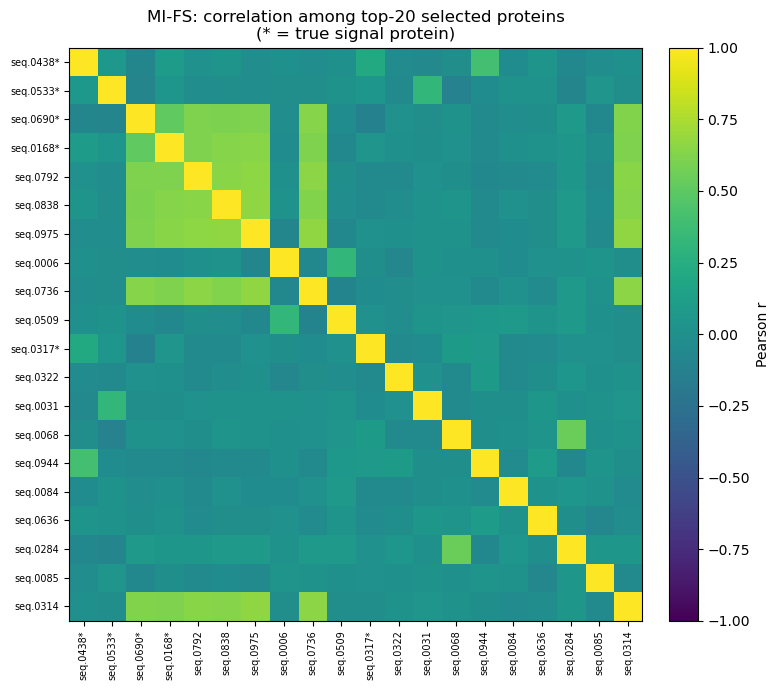

In [32]:
# ==========================================================
# Correlation heatmaps for top-k selected proteins
# ==========================================================
def corr_heatmap(selected_list, title, k=20):
    feats = [p for p in selected_list if p in simdata.columns][:k]
    if len(feats) < 2:
        print(f"Too few features for {title}")
        return

    X = simdata[feats].to_numpy()
    C = np.corrcoef(X, rowvar=False)

    labels = [f"{p}*" if p in signal_proteins else p for p in feats]

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(C, vmin=-1, vmax=1)
    ax.set_title(title + "\n(* = true signal protein)")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pearson r")

    plt.tight_layout()
    plt.show()

corr_heatmap(rank_ttest, "t-test: correlation among top-20 selected proteins", k=20)
corr_heatmap(rank_mi_fs, "MI-FS: correlation among top-20 selected proteins", k=20)